## Ingen maskininlärning ska göras här, bara datainsamling och visualisering.

In [1]:
%pip install openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


--- Datasetets storlek och datatyper ---
<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB
None

--- Statistisk sammanfattning ---
       satisfaction_level  last_evaluation  number_project  \
count        14999.000000

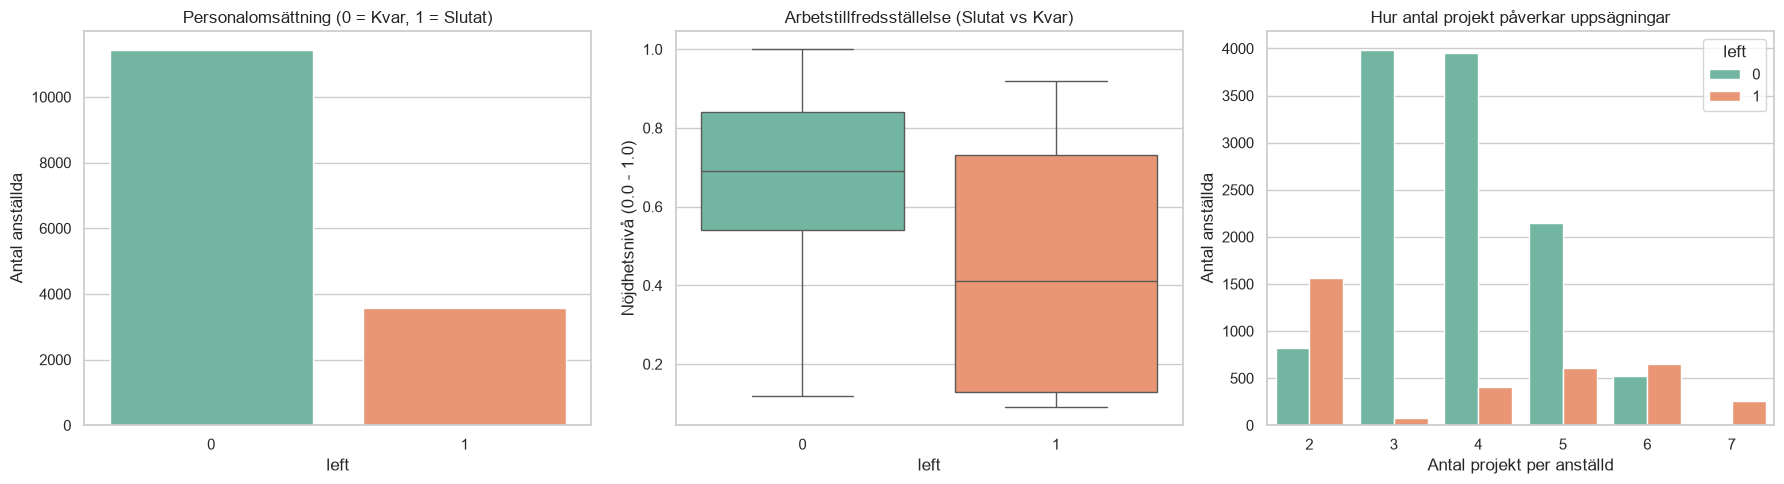

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# a) Läs in datan
df = pd.read_excel("hr_employee_data.xlsx")

# b) Skriv ut grundläggande information för att förstå datan
print("--- Datasetets storlek och datatyper ---")
print(df.info())
print("\n--- Statistisk sammanfattning ---")
print(df.describe())

# c) Skapa professionella visualiseringar för ledningsgruppen
sns.set_theme(style="whitegrid") # Ger graferna en ren och snygg bakgrund
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Skapar en rad med tre grafer

# Graf 1: Hur många har slutat ('left')?
sns.countplot(data=df, x='left', ax=axes[0], hue='left', palette='Set2', legend=False)
axes[0].set_title('Personalomsättning (0 = Kvar, 1 = Slutat)')
axes[0].set_ylabel('Antal anställda')

# Graf 2: Arbetstillfredsställelse för de som slutat vs stannat
sns.boxplot(data=df, x='left', y='satisfaction_level', ax=axes[1], hue='left', palette='Set2', legend=False)
axes[1].set_title('Arbetstillfredsställelse (Slutat vs Kvar)')
axes[1].set_ylabel('Nöjdhetsnivå (0.0 - 1.0)')

# Graf 3: Antal projekt och risken att sluta
sns.countplot(data=df, x='number_project', hue='left', ax=axes[2], palette='Set2')
axes[2].set_title('Hur antal projekt påverkar uppsägningar')
axes[2].set_xlabel('Antal projekt per anställd')
axes[2].set_ylabel('Antal anställda')

# Visa allt snyggt paketerat
plt.tight_layout()
plt.show()